<a href="https://colab.research.google.com/github/Sandesh-Pandey/GenAI_ML_DL_NLP/blob/main/Difussion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

REAL IMAGE DENOISING DEMO

[Upload] Choose an image file:


Saving images (1).jpeg to images (1) (1).jpeg
[Upload] Selected: images (1) (1).jpeg


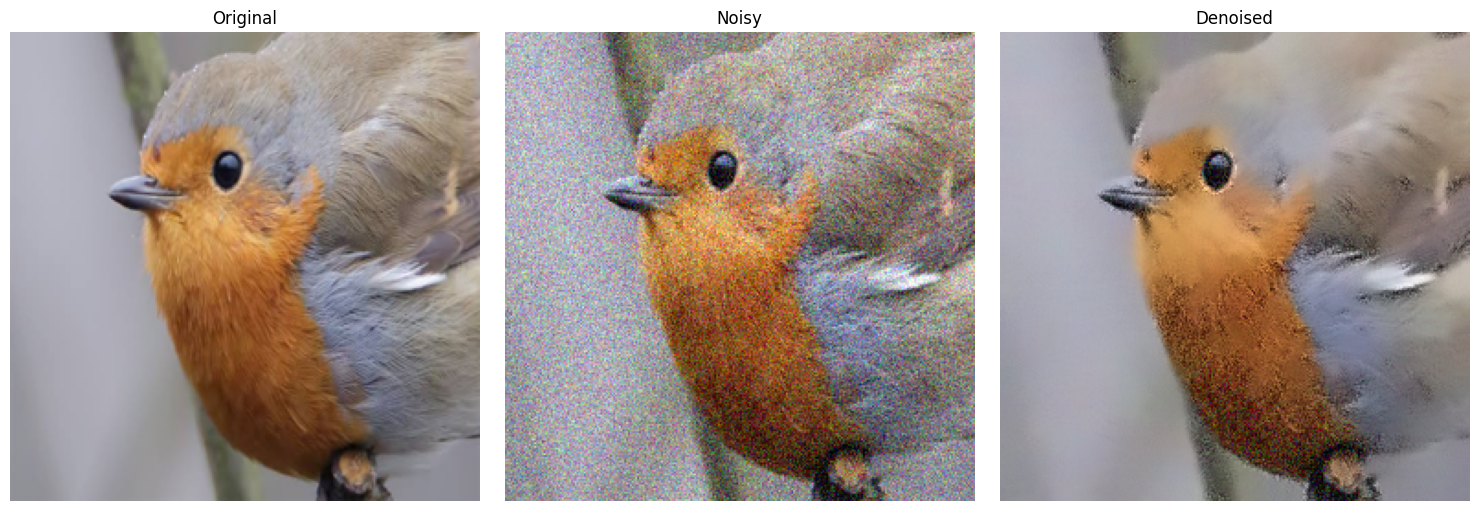


Saved output to: outputs/denoising_result.png


In [16]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# 1. CONFIGURATION
# ============================================================
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NOISE_STD = 25          # noise level for demo, 0-255 scale
IMAGE_SIZE = 256        # resize for presentation

print("=" * 70)
print("REAL IMAGE DENOISING DEMO")
print("=" * 70)

# ============================================================
# 2. IMAGE UPLOAD
# ============================================================
def prompt_upload_image():
    """
    Works in Google Colab or local desktop.
    """
    if "google.colab" in sys.modules:
        from google.colab import files
        print("\n[Upload] Choose an image file:")
        uploaded = files.upload()
        if uploaded:
            filename = list(uploaded.keys())[0]
            print(f"[Upload] Selected: {filename}")
            return filename
        return None

    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)

        print("\n[Upload] Opening file picker...")
        file_path = filedialog.askopenfilename(
            title="Select an Image",
            filetypes=[
                ("Image files", "*.png *.jpg *.jpeg *.bmp *.webp"),
                ("All files", "*.*")
            ]
        )
        root.destroy()

        if file_path:
            print(f"[Upload] Selected: {file_path}")
            return file_path
        return None

    except Exception as e:
        print(f"[Upload] File dialog unavailable: {e}")
        return None

# ============================================================
# 3. LOAD IMAGE
# ============================================================
def load_image(path, size=256):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size))
    return np.array(img)

# ============================================================
# 4. ADD NOISE
# ============================================================
def add_gaussian_noise(image, std=25):
    """
    image: uint8 RGB image in range [0,255]
    std: noise std in 0-255 scale
    """
    noise = np.random.normal(0, std, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

# ============================================================
# 5. DENOISE USING PREBUILT OPENCV METHOD
# ============================================================
def denoise_image(noisy_image):
    """
    OpenCV fast non-local means denoising.
    Works well for demo and doesn't require training.
    """
    denoised = cv2.fastNlMeansDenoisingColored(
        noisy_image,
        None,
        h=10,
        hColor=10,
        templateWindowSize=7,
        searchWindowSize=21
    )
    return denoised

# ============================================================
# 6. DISPLAY RESULTS
# ============================================================
def show_results(original, noisy, denoised):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(noisy)
    axes[1].set_title("Noisy")
    axes[1].axis("off")

    axes[2].imshow(denoised)
    axes[2].set_title("Denoised")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "denoising_result.png"), bbox_inches="tight")
    plt.show()

# ============================================================
# 7. MAIN
# ============================================================
if __name__ == "__main__":
    selected_image = prompt_upload_image()

    if selected_image is None:
        print("No image selected.")
        sys.exit(0)

    original = load_image(selected_image, size=IMAGE_SIZE)
    noisy = add_gaussian_noise(original, std=NOISE_STD)
    denoised = denoise_image(noisy)

    show_results(original, noisy, denoised)

    print(f"\nSaved output to: {os.path.join(OUTPUT_DIR, 'denoising_result.png')}")